# This note book evaluate the k for problems

In [1]:
from rbnbr.problems.max_cut import MaxCutProblem
from rbnbr.solver.quantum.qrr import QRRMaxCutSolver
import numpy as np


In [54]:
qrr = QRRMaxCutSolver()
def get_k(problem):
    
    graph = problem.graph
    Z = qrr.get_corr_analytic(graph)
    
    evals, evecs = np.linalg.eigh(Z)
    # print(np.sum(eigenvectors - eigenvectors.T))
    evecs = evecs.T
    sign_vecs = (1 + np.sign(evecs)) // 2 # 0 / 1 solution
    
    
    k = 0 
    candidates = []
    for i in range(sign_vecs.shape[0]):
        sol = sign_vecs[i].astype(int).tolist()
        cost = problem.evaluate_solution(sol)
        candidates.append((cost, sol, evecs[i, :], evals[i], i))
    # print(evals)
        
    candidates.sort(reverse=True, key=lambda x: x[0])
    
    result = {}
    
    result['best_solution_index'] = candidates[0][4]
    result['best_solution_cost'] = candidates[0][0]
    result['best_evals'] = candidates[0][3]
    
    # descending order by the eigenvalue
    candidates.sort(reverse=True, key=lambda x: x[3])
    
    result['max_eigenvalue_index'] = candidates[0][4]
    result['max_eigenvalue_cost'] = candidates[0][0]
    
    result['min_eigenvalue_index'] = candidates[-1][4]
    result['min_eigenvalue_cost'] = candidates[-1][0]
    
    # descending order by the spectral radius
    candidates.sort(reverse=True, key=lambda x: np.abs(x[3]))
    
    result['max_spectral_radius_index'] = candidates[0][4]
    result['max_spectral_radius_cost'] = candidates[0][0]

    result['min_spectral_radius_index'] = candidates[-1][4]
    result['min_spectral_radius_cost'] = candidates[-1][0]
    
    
    result['spectral_radius'] = candidates[0][3]
    
    return result
    
                    


In [55]:
test_problem = MaxCutProblem.generate_random_maxcut_problem(10, p=0.5)
print(get_k(test_problem))

{'best_solution_index': 2, 'best_solution_cost': 15.0, 'best_evals': -0.19670192083131063, 'max_eigenvalue_index': 9, 'max_eigenvalue_cost': 14.0, 'min_eigenvalue_index': 0, 'min_eigenvalue_cost': 12.0, 'max_spectral_radius_index': 0, 'max_spectral_radius_cost': 12.0, 'min_spectral_radius_index': 5, 'min_spectral_radius_cost': 12.0, 'spectral_radius': -2.0185136403873702}


In [56]:
import pandas as pd
from tqdm.notebook import tqdm


n_each = 25

results = []

total_iterations = len(range(10, 101, 10)) * n_each
with tqdm(total=total_iterations, desc="Total Progress") as pbar:
    for n in range(10, 101, 10):
        for _ in range(n_each):
            test_problem = MaxCutProblem.generate_random_maxcut_problem(n, p=0.5, solve=False)
            result = get_k(test_problem)
            result['n_nodes'] = test_problem.N
            results.append(result)
            pbar.update(1)

df = pd.DataFrame(results)



Total Progress:   0%|          | 0/250 [00:00<?, ?it/s]

In [57]:
show_df = pd.DataFrame()

sub_df = df[['n_nodes', 'best_solution_cost', 'best_solution_index', 'max_eigenvalue_cost', 'min_eigenvalue_cost', 'max_spectral_radius_cost', 'max_spectral_radius_index', 'min_spectral_radius_cost', 'min_spectral_radius_index']]


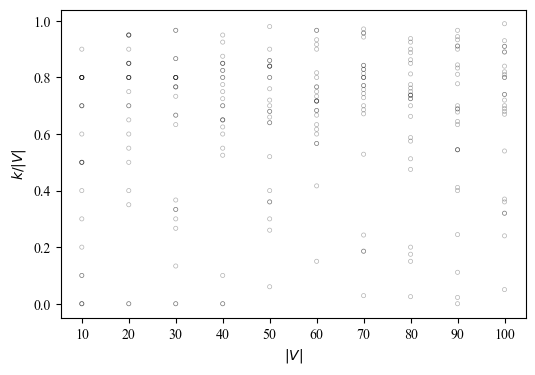

In [82]:
from matplotlib import pyplot as plt


y = 1 - (sub_df['best_solution_index']+1) / sub_df['n_nodes'] + np.random.randn(len(sub_df)) * 0.0

plt.figure(figsize=(6, 4))
plt.scatter(sub_df['n_nodes'], y, marker='.', edgecolors='black', linewidths=0.5, alpha=0.3, c='none')

plt.rcParams['font.family'] = 'Times New Roman'
plt.xlabel('$|V|$', fontname='Times New Roman')
plt.ylabel('$k/|V|$', fontname='Times New Roman')

# Set x ticks for all values
unique_nodes = sorted(sub_df['n_nodes'].unique())
plt.xticks(unique_nodes)
# plt.ylim(1.1, -0.1)  

# Save as PGF for LaTeX integration
plt.savefig('./img/node_ratio_plot.pgf', format='pgf', bbox_inches='tight')






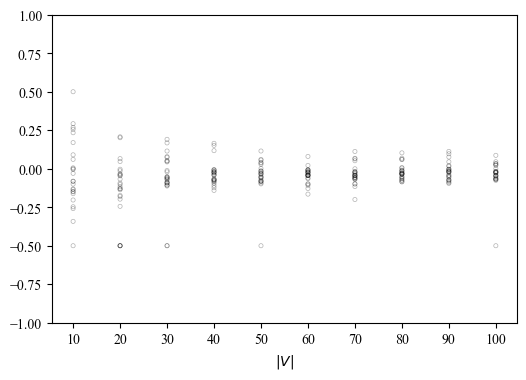

In [74]:
from matplotlib import pyplot as plt


y = 0.5* df['best_evals'] / (df['spectral_radius'].abs()) + np.random.randn(len(df)) * 0.0


plt.figure(figsize=(6, 4))
plt.scatter(df['n_nodes'], y, marker='.', edgecolors='black', linewidths=0.5, alpha=0.3, c='none')

plt.rcParams['font.family'] = 'Times New Roman'
plt.xlabel('$|V|$', fontname='Times New Roman')
plt.ylabel('', fontname='Times New Roman')
# Set y-axis limits to -1 and 1
plt.ylim(-1, 1)

# Set x ticks for all values
unique_nodes = sorted(sub_df['n_nodes'].unique())
plt.xticks(unique_nodes)

# Save as PGF for LaTeX integration
plt.savefig('./img/spectral_radius_plot.pgf', format='pgf', bbox_inches='tight')



In [65]:
df['best_evals']

0     -1.212775
1     -0.674664
2     -0.416825
3     -0.774465
4     -0.210332
         ...   
245    3.486743
246   -1.019974
247   -1.611706
248    0.000966
249   -0.442606
Name: best_evals, Length: 250, dtype: float64